# 0. Configuration — Imports et paramètres globaux

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("pandas  :", pd.__version__)
print("numpy   :", np.__version__)
print("matplotlib :", plt.matplotlib.__version__)
print("Tout est prêt !")

pandas  : 3.0.2
numpy   : 2.4.4
matplotlib : 3.10.8
Tout est prêt !


# 1. Chargement des données — Dataset COVID-19 Johns Hopkins

In [2]:
BASE = "https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/"
PATH = "csse_covid_19_data/csse_covid_19_time_series/"

confirmed = pd.read_csv(BASE + PATH + "time_series_covid19_confirmed_global.csv")
deaths    = pd.read_csv(BASE + PATH + "time_series_covid19_deaths_global.csv")
recovered = pd.read_csv(BASE + PATH + "time_series_covid19_recovered_global.csv")

print("Confirmed :", confirmed.shape)
print("Deaths    :", deaths.shape)
print("Recovered :", recovered.shape)
print("Téléchargement réussi !")

Confirmed : (289, 1147)
Deaths    : (289, 1147)
Recovered : (274, 1147)
Téléchargement réussi !


In [3]:
print("=== CONFIRMED ===")
print(confirmed.head(3))
print("\nColonnes :", confirmed.columns[:8].tolist(), "...")

=== CONFIRMED ===
  Province/State Country/Region       Lat       Long  1/22/20  1/23/20  \
0            NaN    Afghanistan  33.93911  67.709953        0        0   
1            NaN        Albania  41.15330  20.168300        0        0   
2            NaN        Algeria  28.03390   1.659600        0        0   

   1/24/20  1/25/20  1/26/20  1/27/20  ...  2/28/23  3/1/23  3/2/23  3/3/23  \
0        0        0        0        0  ...   209322  209340  209358  209362   
1        0        0        0        0  ...   334391  334408  334408  334427   
2        0        0        0        0  ...   271441  271448  271463  271469   

   3/4/23  3/5/23  3/6/23  3/7/23  3/8/23  3/9/23  
0  209369  209390  209406  209436  209451  209451  
1  334427  334427  334427  334427  334443  334457  
2  271469  271477  271477  271490  271494  271496  

[3 rows x 1147 columns]

Colonnes : ['Province/State', 'Country/Region', 'Lat', 'Long', '1/22/20', '1/23/20', '1/24/20', '1/25/20'] ...


In [4]:
print("=== VALEURS MANQUANTES ===")
print("\nConfirmed :")
print(confirmed.isnull().sum().head(6))
print("\nDeaths :")
print(deaths.isnull().sum().head(6))
print("\nRecovered :")
print(recovered.isnull().sum().head(6))

=== VALEURS MANQUANTES ===

Confirmed :
Province/State    198
Country/Region      0
Lat                 2
Long                2
1/22/20             0
1/23/20             0
dtype: int64

Deaths :
Province/State    198
Country/Region      0
Lat                 2
Long                2
1/22/20             0
1/23/20             0
dtype: int64

Recovered :
Province/State    199
Country/Region      0
Lat                 1
Long                1
1/22/20             0
1/23/20             0
dtype: int64


# 2. Nettoyage et restructuration des données

In [5]:
# Maintenant chaque ligne = un pays + une date + une valeur
def nettoyer(df, nom_colonne):
    # Supprimer les colonnes inutiles
    df = df.drop(columns=["Province/State", "Lat", "Long"])
    # Agréger par pays (sommer les régions)
    df = df.groupby("Country/Region").sum().reset_index()
    # Pivoter en format long (une ligne par date)
    df = df.melt(id_vars="Country/Region", var_name="date", value_name=nom_colonne)
    # Convertir la colonne date en datetime
    df["date"] = pd.to_datetime(df["date"])
    return df

df_confirmed = nettoyer(confirmed, "confirmed")
df_deaths    = nettoyer(deaths,    "deaths")
df_recovered = nettoyer(recovered, "recovered")

print("Confirmed :", df_confirmed.shape)
print(df_confirmed.head(5))

C:\Users\DELL\AppData\Local\Temp\ipykernel_12548\2208368664.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df = df.groupby("Country/Region").sum().reset_index()
C:\Users\DELL\AppData\Local\Temp\ipykernel_12548\2208368664.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["date"] = pd.to_datetime(df["date"])
C:\Users\DELL\AppData\Local\Temp\ipykernel_12548\2208368664.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented fr

Confirmed : (229743, 3)
  Country/Region       date  confirmed
0    Afghanistan 2020-01-22          0
1        Albania 2020-01-22          0
2        Algeria 2020-01-22          0
3        Andorra 2020-01-22          0
4         Angola 2020-01-22          0


C:\Users\DELL\AppData\Local\Temp\ipykernel_12548\2208368664.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df = df.groupby("Country/Region").sum().reset_index()
C:\Users\DELL\AppData\Local\Temp\ipykernel_12548\2208368664.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["date"] = pd.to_datetime(df["date"])


In [6]:
# Fusion des trois tableaux en un seul
df = df_confirmed.merge(df_deaths,    on=["Country/Region", "date"]) \
                 .merge(df_recovered, on=["Country/Region", "date"])

# Trier par pays puis par date
df = df.sort_values(["Country/Region", "date"]).reset_index(drop=True)

print("Shape final :", df.shape)
print(df.head(5))

Shape final : (229743, 5)
  Country/Region       date  confirmed  deaths  recovered
0    Afghanistan 2020-01-22          0       0          0
1    Afghanistan 2020-01-23          0       0          0
2    Afghanistan 2020-01-24          0       0          0
3    Afghanistan 2020-01-25          0       0          0
4    Afghanistan 2020-01-26          0       0          0


# 3. Sélection du pays — Algérie

In [7]:
# Filtrer uniquement l'Algérie
df_algerie = df[df["Country/Region"] == "Algeria"].copy()
df_algerie = df_algerie.sort_values("date").reset_index(drop=True)

print("Nombre de jours :", len(df_algerie))
print("Période : du", df_algerie["date"].min(), "au", df_algerie["date"].max())
print(df_algerie.head(5))

Nombre de jours : 1143
Période : du 2020-01-22 00:00:00 au 2023-03-09 00:00:00
  Country/Region       date  confirmed  deaths  recovered
0        Algeria 2020-01-22          0       0          0
1        Algeria 2020-01-23          0       0          0
2        Algeria 2020-01-24          0       0          0
3        Algeria 2020-01-25          0       0          0
4        Algeria 2020-01-26          0       0          0


In [8]:
# Calculer les nouveaux cas journaliers (différence entre chaque jour)
df_algerie["new_cases"]    = df_algerie["confirmed"].diff().fillna(0).clip(lower=0)
df_algerie["new_deaths"]   = df_algerie["deaths"].diff().fillna(0).clip(lower=0)
df_algerie["new_recovered"]= df_algerie["recovered"].diff().fillna(0).clip(lower=0)

print(df_algerie[["date", "confirmed", "new_cases", "new_deaths"]].head(10))

        date  confirmed  new_cases  new_deaths
0 2020-01-22          0        0.0         0.0
1 2020-01-23          0        0.0         0.0
2 2020-01-24          0        0.0         0.0
3 2020-01-25          0        0.0         0.0
4 2020-01-26          0        0.0         0.0
5 2020-01-27          0        0.0         0.0
6 2020-01-28          0        0.0         0.0
7 2020-01-29          0        0.0         0.0
8 2020-01-30          0        0.0         0.0
9 2020-01-31          0        0.0         0.0


In [9]:
# Trouver le premier jour avec des cas en Algérie
premier_cas = df_algerie[df_algerie["new_cases"] > 0].iloc[0]
print("Premier cas en Algérie :")
print(premier_cas[["date", "new_cases", "confirmed"]])

Premier cas en Algérie :
date         2020-02-25 00:00:00
new_cases                    1.0
confirmed                      1
Name: 34, dtype: object


In [10]:
print("=== FORME DU DATASET ===")
print("Lignes x Colonnes :", df_algerie.shape)

print("\n=== COLONNES ET TYPES ===")
print(df_algerie.dtypes)

print("\n=== APERÇU GÉNÉRAL ===")
print(df_algerie.describe())

print("\n=== 5 PREMIÈRES LIGNES ===")
print(df_algerie.head())

print("\n=== 5 DERNIÈRES LIGNES ===")
print(df_algerie.tail())

=== FORME DU DATASET ===
Lignes x Colonnes : (1143, 8)

=== COLONNES ET TYPES ===
Country/Region               str
date              datetime64[us]
confirmed                  int64
deaths                     int64
recovered                  int64
new_cases                float64
new_deaths               float64
new_recovered            float64
dtype: object

=== APERÇU GÉNÉRAL ===
                      date      confirmed       deaths      recovered  \
count                 1143    1143.000000  1143.000000    1143.000000   
mean   2021-08-15 00:00:00  159878.958880  4288.079615   22458.646544   
min    2020-01-22 00:00:00       0.000000     0.000000       0.000000   
25%    2020-11-02 12:00:00   58776.500000  1980.000000       0.000000   
50%    2021-08-15 00:00:00  187258.000000  4794.000000       0.000000   
75%    2022-05-27 12:00:00  265871.500000  6875.000000   38703.000000   
max    2023-03-09 00:00:00  271496.000000  6881.000000  118409.000000   
std                    NaN  1007

# 4. Visualisation EDA — Algérie

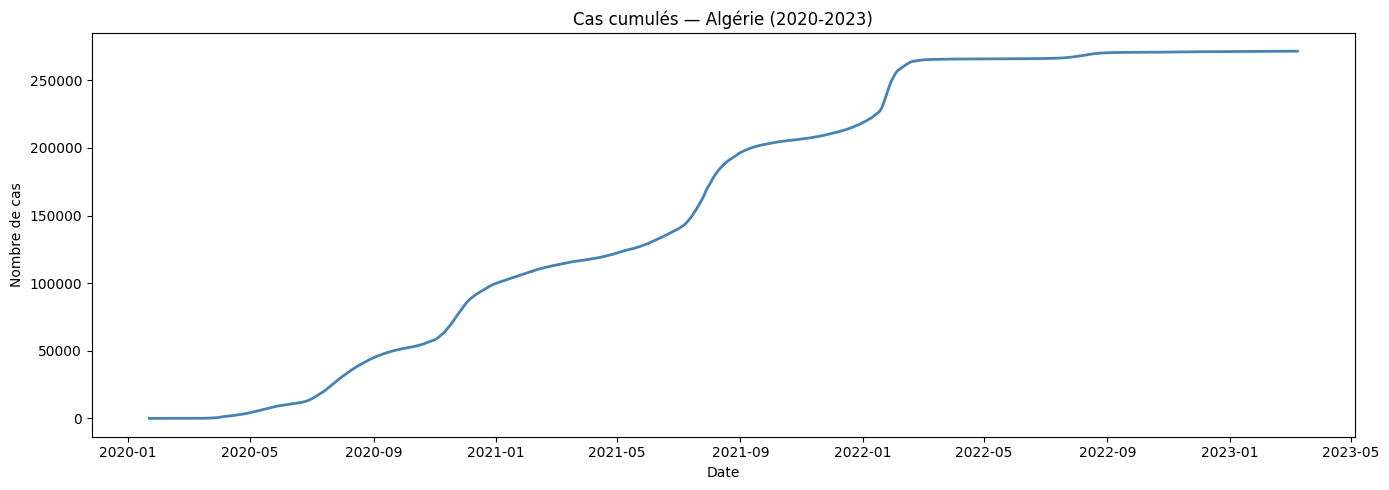

In [11]:
# Graphique 1 : Cas cumulés
plt.figure(figsize=(14, 5))
plt.plot(df_algerie["date"], df_algerie["confirmed"], color="steelblue", linewidth=2)
plt.title("Cas cumulés — Algérie (2020-2023)")
plt.xlabel("Date")
plt.ylabel("Nombre de cas")
plt.tight_layout()
plt.savefig("../outputs/1_cas_cumules.png", dpi=150)
plt.show()

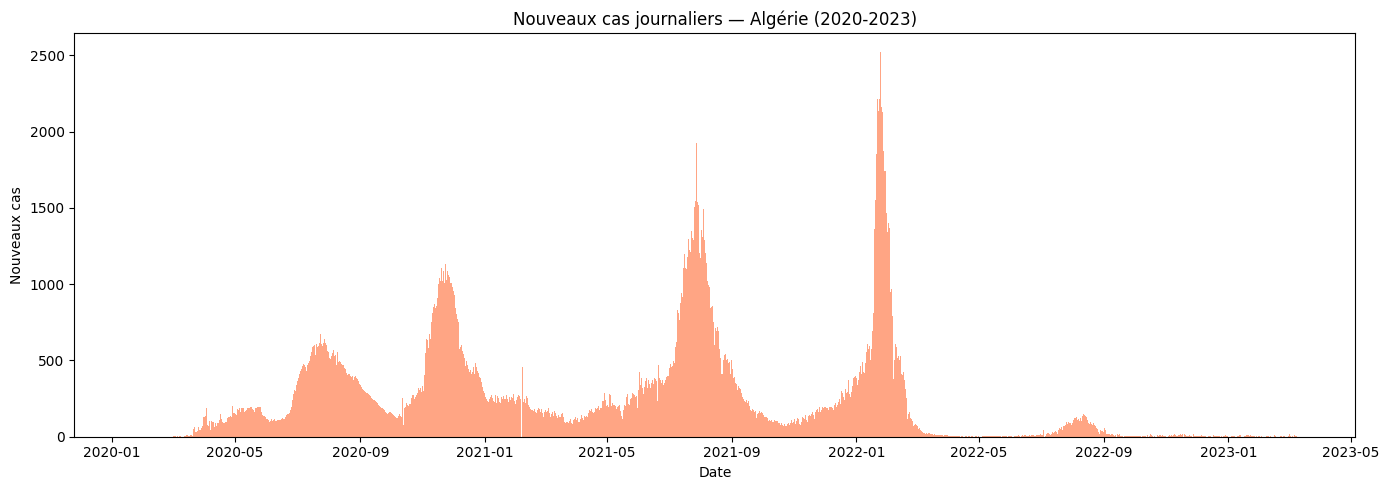

In [12]:
# Graphique 2 : Nouveaux cas journaliers
plt.figure(figsize=(14, 5))
plt.bar(df_algerie["date"], df_algerie["new_cases"], 
        color="coral", width=1, alpha=0.7)
plt.title("Nouveaux cas journaliers — Algérie (2020-2023)")
plt.xlabel("Date")
plt.ylabel("Nouveaux cas")
plt.tight_layout()
plt.savefig("../outputs/2_nouveaux_cas.png", dpi=150)
plt.show()

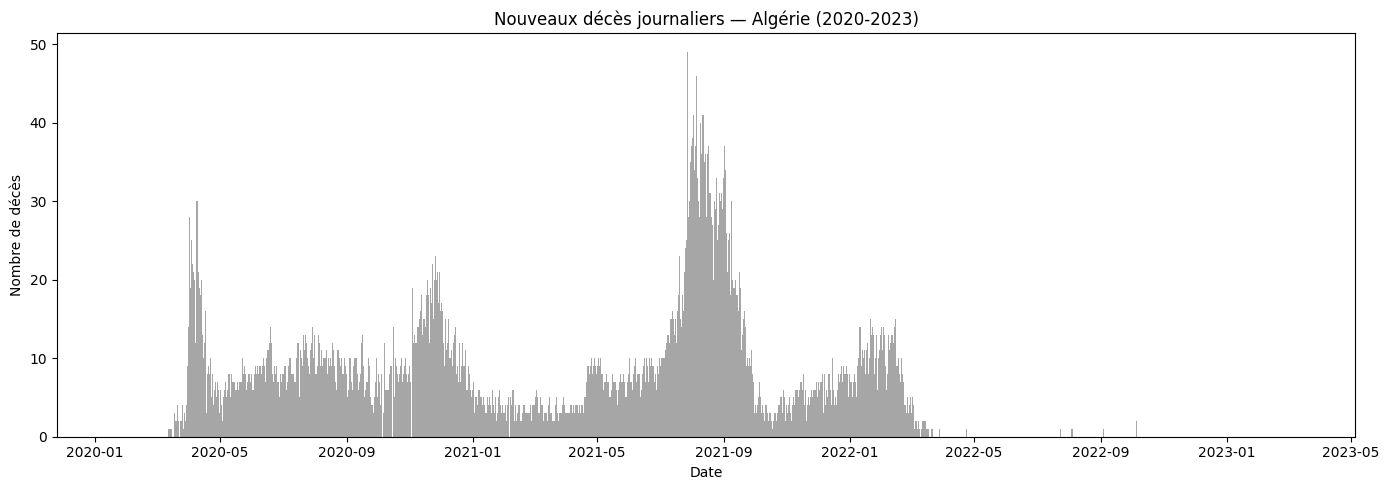

In [13]:
# Graphique 4 : Nouveaux décès journaliers (sans moyenne mobile)
plt.figure(figsize=(14, 5))
plt.bar(df_algerie["date"], df_algerie["new_deaths"],
        color="gray", width=1, alpha=0.7, label="Décès journaliers")
plt.title("Nouveaux décès journaliers — Algérie (2020-2023)")
plt.xlabel("Date")
plt.ylabel("Nombre de décès")
plt.tight_layout()
plt.savefig("../outputs/4_deces.png", dpi=150)
plt.show()

 — Feature Engineering & Préparation LSTM

## 0. Seeds aléatoires — À exécuter en premier

In [14]:
import random
import os

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

print("Seeds fixées avec succès — valeur :", SEED)

Seeds fixées avec succès — valeur : 42


## 1. Création des features supplémentaires

In [15]:
# Moyenne mobile 7 jours
df_algerie["new_cases_7d"] = df_algerie["new_cases"].rolling(7).mean()

# Taux de croissance journalier
df_algerie["growth_rate"] = df_algerie["confirmed"].pct_change().fillna(0).clip(-1, 5)

# Jour de la semaine (0=lundi, 6=dimanche)
df_algerie["day_of_week"] = df_algerie["date"].dt.dayofweek

# Lag features (valeurs des jours précédents)
df_algerie["lag_1"] = df_algerie["new_cases_7d"].shift(1)
df_algerie["lag_3"] = df_algerie["new_cases_7d"].shift(3)
df_algerie["lag_7"] = df_algerie["new_cases_7d"].shift(7)

# Supprimer les lignes avec NaN créées par les lags
df_algerie = df_algerie.dropna().reset_index(drop=True)

print("Shape après feature engineering :", df_algerie.shape)
print("\nColonnes disponibles :")
print(df_algerie.columns.tolist())
print("\nAperçu :")
print(df_algerie[["date", "new_cases_7d", "growth_rate", "day_of_week", "lag_1", "lag_3", "lag_7"]].head())

Shape après feature engineering : (1130, 14)

Colonnes disponibles :
['Country/Region', 'date', 'confirmed', 'deaths', 'recovered', 'new_cases', 'new_deaths', 'new_recovered', 'new_cases_7d', 'growth_rate', 'day_of_week', 'lag_1', 'lag_3', 'lag_7']

Aperçu :
        date  new_cases_7d  growth_rate  day_of_week  lag_1  lag_3  lag_7
0 2020-02-04           0.0          0.0            1    0.0    0.0    0.0
1 2020-02-05           0.0          0.0            2    0.0    0.0    0.0
2 2020-02-06           0.0          0.0            3    0.0    0.0    0.0
3 2020-02-07           0.0          0.0            4    0.0    0.0    0.0
4 2020-02-08           0.0          0.0            5    0.0    0.0    0.0


## 2. Normalisation des données

In [16]:
from sklearn.preprocessing import MinMaxScaler
import joblib

# Les 6 features qu'on va utiliser
FEATURES = ["new_cases_7d", "growth_rate", "day_of_week", "lag_1", "lag_3", "lag_7"]
TARGET    = "new_cases_7d"

print("Features utilisées :", FEATURES)
print("Variable cible :", TARGET)
print("\nAperçu des features avant normalisation :")
print(df_algerie[FEATURES].describe())

Features utilisées : ['new_cases_7d', 'growth_rate', 'day_of_week', 'lag_1', 'lag_3', 'lag_7']
Variable cible : new_cases_7d

Aperçu des features avant normalisation :
       new_cases_7d  growth_rate  day_of_week        lag_1        lag_3  \
count   1130.000000  1130.000000  1130.000000  1130.000000  1130.000000   
mean     240.249305     0.017471     2.997345   240.245133   240.233123   
std      328.258444     0.169987     1.999334   328.261470   328.270143   
min        0.000000     0.000000     0.000000     0.000000     0.000000   
25%        8.750000     0.000041     1.000000     8.750000     8.750000   
50%      141.500000     0.001369     3.000000   141.500000   141.500000   
75%      308.428571     0.005352     5.000000   308.428571   308.428571   
max     2177.571429     5.000000     6.000000  2177.571429  2177.571429   

             lag_7  
count  1130.000000  
mean    240.215803  
std     328.282698  
min       0.000000  
25%       8.750000  
50%     141.500000  
75%     3

In [17]:
# Créer le scaler et normaliser
scaler = MinMaxScaler()

# Fit UNIQUEMENT sur les données (on fittera plus tard sur train seulement)
data = df_algerie[FEATURES].values

print("Forme des données :", data.shape)
print("\nAvant normalisation — première ligne :")
print(data[0])

Forme des données : (1130, 6)

Avant normalisation — première ligne :
[0. 0. 1. 0. 0. 0.]


In [18]:
# Taille des ensembles
n = len(data)
n_train = int(n * 0.70)
n_val   = int(n * 0.85)

print("Total jours      :", n)
print("Train            :", n_train, "jours")
print("Validation       :", n_val - n_train, "jours")
print("Test             :", n - n_val, "jours")
print("\nTrain : du", df_algerie["date"].iloc[0].date(), 
      "au", df_algerie["date"].iloc[n_train-1].date())
print("Val   : du", df_algerie["date"].iloc[n_train].date(), 
      "au", df_algerie["date"].iloc[n_val-1].date())
print("Test  : du", df_algerie["date"].iloc[n_val].date(), 
      "au", df_algerie["date"].iloc[-1].date())

Total jours      : 1130
Train            : 791 jours
Validation       : 169 jours
Test             : 170 jours

Train : du 2020-02-04 au 2022-04-04
Val   : du 2022-04-05 au 2022-09-20
Test  : du 2022-09-21 au 2023-03-09


In [19]:
# Fit du scaler sur train uniquement
scaler = MinMaxScaler()
scaler.fit(data[:n_train])

# Transformer les trois ensembles
data_scaled = scaler.transform(data)

print("Avant normalisation :", data[100])
print("Après normalisation :", data_scaled[100])

Avant normalisation : [1.80000000e+02 3.02254918e-02 3.00000000e+00 1.79428571e+02
 1.77571429e+02 1.68000000e+02]
Après normalisation : [0.08266089 0.0060451  0.5        0.08239848 0.08154563 0.07715017]


In [20]:
# Sauvegarder le scaler pour plus tard
joblib.dump(scaler, "../models/scaler.pkl")
print("Scaler sauvegardé dans models/scaler.pkl")

Scaler sauvegardé dans models/scaler.pkl


## 3. Construction des fenêtres temporelles

In [21]:
WINDOW = 14  # 14 jours d'historique pour prédire le lendemain

X, y = [], []

for i in range(WINDOW, len(data_scaled)):
    X.append(data_scaled[i-WINDOW:i])        # 14 jours de features
    y.append(data_scaled[i, 0])              # valeur new_cases_7d du jour suivant

X = np.array(X)
y = np.array(y)

print("Forme de X :", X.shape)
print("Forme de y :", y.shape)
print("\nExemple — X[0] (14 jours de données) :")
print(X[0])
print("\nExemple — y[0] (valeur à prédire) :")
print(y[0])

Forme de X : (1116, 14, 6)
Forme de y : (1116,)

Exemple — X[0] (14 jours de données) :
[[0.         0.         0.16666667 0.         0.         0.        ]
 [0.         0.         0.33333333 0.         0.         0.        ]
 [0.         0.         0.5        0.         0.         0.        ]
 [0.         0.         0.66666667 0.         0.         0.        ]
 [0.         0.         0.83333333 0.         0.         0.        ]
 [0.         0.         1.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.        ]
 [0.         0.         0.16666667 0.         0.         0.        ]
 [0.         0.         0.33333333 0.         0.         0.        ]
 [0.         0.         0.5        0.         0.         0.        ]
 [0.         0.         0.66666667 0.         0.         0.        ]
 [0.         0.         0.83333333 0.         0.         0.        ]
 [0.         0.         1.         0.         0.         0.        ]
 [0.         0.

In [22]:
# Split chronologique de X et y
X_train = X[:n_train]
y_train = y[:n_train]

X_val   = X[n_train:n_val]
y_val   = y[n_train:n_val]

X_test  = X[n_val:]
y_test  = y[n_val:]

print("X_train :", X_train.shape, "| y_train :", y_train.shape)
print("X_val   :", X_val.shape,   "| y_val   :", y_val.shape)
print("X_test  :", X_test.shape,  "| y_test  :", y_test.shape)

X_train : (791, 14, 6) | y_train : (791,)
X_val   : (169, 14, 6) | y_val   : (169,)
X_test  : (156, 14, 6) | y_test  : (156,)


# MODÈLE 1 — LSTM

In [23]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

tf.random.set_seed(SEED)

print("TensorFlow version :", tf.__version__)
print("Keras version      :", tf.keras.__version__)

TensorFlow version : 2.21.0
Keras version      : 3.14.0


## 1. Architecture du modèle LSTM

In [24]:
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(WINDOW, len(FEATURES))),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(1)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

model.summary()

c:\Users\DELL\Desktop\Cours-univ\Deep learning\DL_Epidemie-main\DL_Epidemie-main\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 14, 64)         │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,137 (121.63 KB)

 Trainable params: 31,137 (121.63 KB)

 Non-trainable params: 0 (0.00 B)

## 2. Entraînement du modèle LSTM

In [25]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=15,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint("../models/best_model_lstm.h5", monitor="val_loss",
                    save_best_only=True, verbose=0),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                      patience=7, min_lr=1e-6, verbose=1),
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

print("\nEntraînement terminé !")

Epoch 1/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0188 - mae: 0.0876

25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 72ms/step - loss: 0.0132 - mae: 0.0722 - val_loss: 4.3036e-04 - val_mae: 0.0190 - learning_rate: 0.0010
Epoch 2/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0069 - mae: 0.0447 - val_loss: 0.0011 - val_mae: 0.0329 - learning_rate: 0.0010
Epoch 3/200
23/25 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0045 - mae: 0.0376

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0050 - mae: 0.0381 - val_loss: 2.4312e-04 - val_mae: 0.0143 - learning_rate: 0.0010
Epoch 4/200
23/25 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0038 - mae: 0.0337

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0035 - mae: 0.0331 - val_loss: 1.0350e-04 - val_mae: 0.0090 - learning_rate: 0.0010
Epoch 5/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0024 - mae: 0.0297 - val_loss: 3.5060e-04 - val_mae: 0.0180 - learning_rate: 0.0010
Epoch 6/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0027 - mae: 0.0295

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0026 - mae: 0.0298 - val_loss: 6.8140e-05 - val_mae: 0.0079 - learning_rate: 0.0010
Epoch 7/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0026 - mae: 0.0300

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0026 - mae: 0.0310 - val_loss: 6.3566e-05 - val_mae: 0.0076 - learning_rate: 0.0010
Epoch 8/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0023 - mae: 0.0303 - val_loss: 2.7654e-04 - val_mae: 0.0155 - learning_rate: 0.0010
Epoch 9/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0018 - mae: 0.0260 - val_loss: 7.8700e-05 - val_mae: 0.0082 - learning_rate: 0.0010
Epoch 10/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0021 - mae: 0.0283 - val_loss: 1.9484e-04 - val_mae: 0.0130 - learning_rate: 0.0010
Epoch 11/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0017 - mae: 0.0253
Epoch 11: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0017 - mae: 0.0259 - val_loss: 3.5247e-04 - val_mae: 0.0182 - learning_rate: 0.0010
Epoch 12/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0021 - mae: 0.0241

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0019 - mae: 0.0236 - val_loss: 5.0655e-05 - val_mae: 0.0067 - learning_rate: 5.0000e-04
Epoch 13/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0015 - mae: 0.0232 - val_loss: 2.3030e-04 - val_mae: 0.0145 - learning_rate: 5.0000e-04
Epoch 14/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0017 - mae: 0.0236 - val_loss: 9.0459e-05 - val_mae: 0.0086 - learning_rate: 5.0000e-04
Epoch 15/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0019 - mae: 0.0237

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0017 - mae: 0.0240 - val_loss: 2.5796e-05 - val_mae: 0.0043 - learning_rate: 5.0000e-04
Epoch 16/200
23/25 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0015 - mae: 0.0213

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0015 - mae: 0.0226 - val_loss: 2.4764e-05 - val_mae: 0.0039 - learning_rate: 5.0000e-04
Epoch 17/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0014 - mae: 0.0225 - val_loss: 4.5019e-05 - val_mae: 0.0062 - learning_rate: 5.0000e-04
Epoch 18/200
23/25 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0016 - mae: 0.0230
Epoch 18: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0015 - mae: 0.0227 - val_loss: 9.3895e-05 - val_mae: 0.0088 - learning_rate: 5.0000e-04
Epoch 19/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0014 - mae: 0.0206 - val_loss: 4.1619e-05 - val_mae: 0.0060 - learning_rate: 2.5000e-04
Epoch 20/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0011 - mae: 0.0205 - val_loss: 9.0609e-05 - val_mae: 0.0087 - learning_rate: 2.5000e-04
Epoch 21/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0013 - mae: 0.0204 - val_loss: 7.6775e-05 - val_m

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0013 - mae: 0.0211 - val_loss: 2.0910e-05 - val_mae: 0.0034 - learning_rate: 2.5000e-04
Epoch 24/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0013 - mae: 0.0220 - val_loss: 4.9211e-05 - val_mae: 0.0063 - learning_rate: 2.5000e-04
Epoch 25/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0013 - mae: 0.0212
Epoch 25: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0013 - mae: 0.0212 - val_loss: 2.2026e-05 - val_mae: 0.0036 - learning_rate: 2.5000e-04
Epoch 26/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0010 - mae: 0.0197 - val_loss: 1.4938e-04 - val_mae: 0.0114 - learning_rate: 1.2500e-04
Epoch 27/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0013 - mae: 0.0203 - val_loss: 9.9816e-05 - val_mae: 0.0091 - learning_rate: 1.2500e-04
Epoch 28/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0013 - mae: 0.0197 - val_loss: 1.3653e-04 - val_m

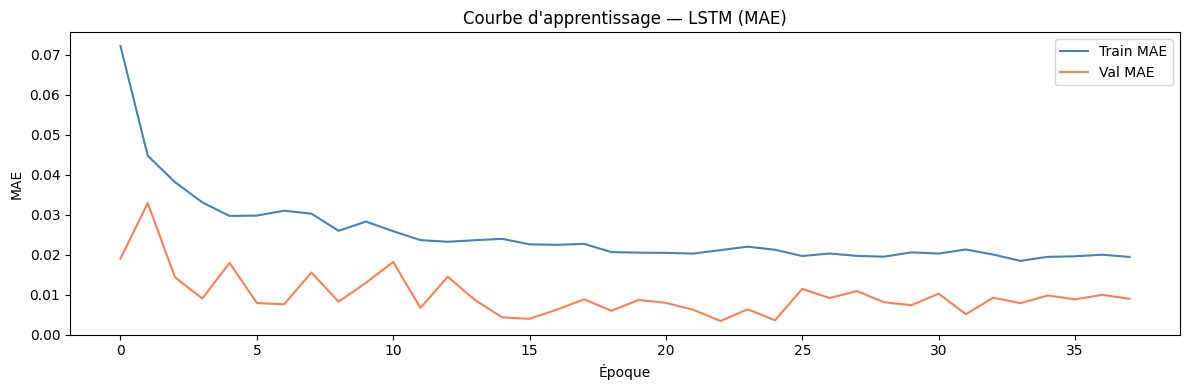

In [26]:
plt.figure(figsize=(12, 4))
plt.plot(history.history["mae"],     label="Train MAE", color="steelblue")
plt.plot(history.history["val_mae"], label="Val MAE",   color="coral")
plt.title("Courbe d'apprentissage — LSTM (MAE)")
plt.xlabel("Époque")
plt.ylabel("MAE")
plt.legend()
plt.tight_layout()
plt.savefig("../outputs/5_learning_curve_lstm_mae.png", dpi=150)
plt.show()

# MODÈLE 2 — GRU

In [27]:
from tensorflow.keras.layers import GRU

tf.random.set_seed(SEED)

model_gru = Sequential([
    GRU(64, return_sequences=True, input_shape=(WINDOW, len(FEATURES))),
    Dropout(0.2),
    GRU(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(1)
])

model_gru.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

model_gru.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 14, 64)         │        13,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,777 (92.88 KB)

 Trainable params: 23,777 (92.88 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
callbacks_gru = [
    EarlyStopping(monitor="val_loss", patience=15,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint("../models/best_model_gru.h5", monitor="val_loss",
                    save_best_only=True, verbose=0),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                      patience=7, min_lr=1e-6, verbose=1),
]

history_gru = model_gru.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=32,
    callbacks=callbacks_gru,
    verbose=1
)

print("\nEntraînement GRU terminé !")

Epoch 1/200
24/25 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0233 - mae: 0.0979

25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 73ms/step - loss: 0.0150 - mae: 0.0773 - val_loss: 9.2009e-05 - val_mae: 0.0069 - learning_rate: 0.0010
Epoch 2/200
24/25 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0052 - mae: 0.0457

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0047 - mae: 0.0420 - val_loss: 5.7900e-05 - val_mae: 0.0064 - learning_rate: 0.0010
Epoch 3/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0031 - mae: 0.0327 - val_loss: 1.0525e-04 - val_mae: 0.0090 - learning_rate: 0.0010
Epoch 4/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0026 - mae: 0.0300 - val_loss: 2.1978e-04 - val_mae: 0.0138 - learning_rate: 0.0010
Epoch 5/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0022 - mae: 0.0294 - val_loss: 3.4580e-04 - val_mae: 0.0182 - learning_rate: 0.0010
Epoch 6/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0021 - mae: 0.0288

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0020 - mae: 0.0282 - val_loss: 3.5063e-05 - val_mae: 0.0051 - learning_rate: 0.0010
Epoch 7/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0021 - mae: 0.0270 - val_loss: 1.5828e-04 - val_mae: 0.0118 - learning_rate: 0.0010
Epoch 8/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0022 - mae: 0.0289
Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0020 - mae: 0.0283 - val_loss: 7.8378e-05 - val_mae: 0.0078 - learning_rate: 0.0010
Epoch 9/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0013 - mae: 0.0230 - val_loss: 9.8900e-05 - val_mae: 0.0091 - learning_rate: 5.0000e-04
Epoch 10/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0014 - mae: 0.0227

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0014 - mae: 0.0232 - val_loss: 2.4690e-05 - val_mae: 0.0038 - learning_rate: 5.0000e-04
Epoch 11/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0016 - mae: 0.0228 - val_loss: 6.9215e-05 - val_mae: 0.0060 - learning_rate: 5.0000e-04
Epoch 12/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0016 - mae: 0.0236 - val_loss: 1.2604e-04 - val_mae: 0.0103 - learning_rate: 5.0000e-04
Epoch 13/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0012 - mae: 0.0216 - val_loss: 4.7489e-05 - val_mae: 0.0062 - learning_rate: 5.0000e-04
Epoch 14/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0012 - mae: 0.0206 - val_loss: 3.3367e-05 - val_mae: 0.0047 - learning_rate: 5.0000e-04
Epoch 15/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 9.8659e-04 - mae: 0.0204
Epoch 15: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0010 - mae: 0.0206 - val_loss: 6.5981e-05 - v

# MODÈLE 3 — Bidirectional LSTM

In [29]:
from tensorflow.keras.layers import Bidirectional

tf.random.set_seed(SEED)

model_bilstm = Sequential([
    Bidirectional(LSTM(64, return_sequences=True), 
                  input_shape=(WINDOW, len(FEATURES))),
    Dropout(0.2),
    Bidirectional(LSTM(32, return_sequences=False)),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(1)
])

model_bilstm.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

model_bilstm.summary()

c:\Users\DELL\Desktop\Cours-univ\Deep learning\DL_Epidemie-main\DL_Epidemie-main\venv\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 14, 128)        │        36,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 14, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 78,625 (307.13 KB)

 Trainable params: 78,625 (307.13 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
callbacks_bilstm = [
    EarlyStopping(monitor="val_loss", patience=15,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint("../models/best_model_bilstm.h5", monitor="val_loss",
                    save_best_only=True, verbose=0),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                      patience=7, min_lr=1e-6, verbose=1),
]

history_bilstm = model_bilstm.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=32,
    callbacks=callbacks_bilstm,
    verbose=1
)

print("\nEntraînement Bidirectional LSTM terminé !")

Epoch 1/200
21/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0156 - mae: 0.0811

25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - loss: 0.0103 - mae: 0.0622 - val_loss: 1.0057e-04 - val_mae: 0.0087 - learning_rate: 0.0010
Epoch 2/200
24/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0039 - mae: 0.0354 

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0037 - mae: 0.0340 - val_loss: 4.9368e-05 - val_mae: 0.0057 - learning_rate: 0.0010
Epoch 3/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0024 - mae: 0.0324 - val_loss: 6.7029e-05 - val_mae: 0.0071 - learning_rate: 0.0010
Epoch 4/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0017 - mae: 0.0255 - val_loss: 1.8238e-04 - val_mae: 0.0123 - learning_rate: 0.0010
Epoch 5/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0019 - mae: 0.0266 - val_loss: 0.0017 - val_mae: 0.0403 - learning_rate: 0.0010
Epoch 6/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0016 - mae: 0.0276 - val_loss: 1.4246e-04 - val_mae: 0.0110 - learning_rate: 0.0010
Epoch 7/200
19/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0014 - mae: 0.0216

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0014 - mae: 0.0215 - val_loss: 4.6452e-05 - val_mae: 0.0063 - learning_rate: 0.0010
Epoch 8/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0013 - mae: 0.0219 
Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0013 - mae: 0.0228 - val_loss: 6.5569e-04 - val_mae: 0.0252 - learning_rate: 0.0010
Epoch 9/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 8.2254e-04 - mae: 0.0187 - val_loss: 3.2766e-04 - val_mae: 0.0176 - learning_rate: 5.0000e-04
Epoch 10/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0010 - mae: 0.0198 - val_loss: 4.7248e-04 - val_mae: 0.0214 - learning_rate: 5.0000e-04
Epoch 11/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 9.7148e-04 - mae: 0.0185 - val_loss: 4.5529e-04 - val_mae: 0.0209 - learning_rate: 5.0000e-04
Epoch 12/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 8.6024e-04 - mae: 0.0186 - val_loss: 3.1844e-04 - val

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 7.0910e-04 - mae: 0.0168 - val_loss: 1.0866e-05 - val_mae: 0.0027 - learning_rate: 2.5000e-04
Epoch 17/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 6.5582e-04 - mae: 0.0157 - val_loss: 1.0063e-04 - val_mae: 0.0095 - learning_rate: 2.5000e-04
Epoch 18/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 6.0158e-04 - mae: 0.0154 - val_loss: 5.1834e-05 - val_mae: 0.0066 - learning_rate: 2.5000e-04
Epoch 19/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 6.9846e-04 - mae: 0.0161 - val_loss: 7.7532e-05 - val_mae: 0.0082 - learning_rate: 2.5000e-04
Epoch 20/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.6797e-04 - mae: 0.0168 - val_loss: 4.7946e-05 - val_mae: 0.0063 - learning_rate: 2.5000e-04
Epoch 21/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 5.3168e-04 - mae: 0.0146 - val_loss: 1.4443e-05 - val_mae: 0.0032 - learning_rate: 2.5000e-04
Epoch 22/200
20/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 6.9017e-04 - mae: 0.01

# MODÈLE 4 — CNN + LSTM

In [31]:
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten

tf.random.set_seed(SEED)

model_cnn_lstm = Sequential([
    Conv1D(filters=64, kernel_size=3, activation="relu",
           input_shape=(WINDOW, len(FEATURES))),
    MaxPooling1D(pool_size=2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(1)
])

model_cnn_lstm.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

model_cnn_lstm.summary()

c:\Users\DELL\Desktop\Cours-univ\Deep learning\DL_Epidemie-main\DL_Epidemie-main\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 12, 64)         │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 6, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 50)             │        23,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,049 (97.85 KB)

 Trainable params: 25,049 (97.85 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
callbacks_cnn = [
    EarlyStopping(monitor="val_loss", patience=15,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint("../models/best_model_cnn_lstm.h5", monitor="val_loss",
                    save_best_only=True, verbose=0),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                      patience=7, min_lr=1e-6, verbose=1),
]

history_cnn = model_cnn_lstm.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=32,
    callbacks=callbacks_cnn,
    verbose=1
)

print("\nEntraînement CNN + LSTM terminé !")

Epoch 1/200
14/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0283 - mae: 0.1120

25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0141 - mae: 0.0769 - val_loss: 6.9546e-04 - val_mae: 0.0231 - learning_rate: 0.0010
Epoch 2/200
13/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0063 - mae: 0.0490 

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0065 - mae: 0.0479 - val_loss: 1.9889e-04 - val_mae: 0.0119 - learning_rate: 0.0010
Epoch 3/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0039 - mae: 0.0361 - val_loss: 2.0733e-04 - val_mae: 0.0118 - learning_rate: 0.0010
Epoch 4/200
15/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0037 - mae: 0.0353 

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0036 - mae: 0.0357 - val_loss: 9.1290e-05 - val_mae: 0.0076 - learning_rate: 0.0010
Epoch 5/200
14/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0026 - mae: 0.0302     

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0026 - mae: 0.0307 - val_loss: 5.1407e-05 - val_mae: 0.0055 - learning_rate: 0.0010
Epoch 6/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0021 - mae: 0.0277 - val_loss: 5.9374e-05 - val_mae: 0.0064 - learning_rate: 0.0010
Epoch 7/200
15/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0024 - mae: 0.0270 

...

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0011 - mae: 0.0191 - val_loss: 2.0392e-05 - val_mae: 0.0035 - learning_rate: 5.0000e-04
Epoch 15/200
14/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 8.5435e-04 - mae: 0.0180 

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 8.3395e-04 - mae: 0.0169 - val_loss: 1.8399e-05 - val_mae: 0.0030 - learning_rate: 5.0000e-04
Epoch 16/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 9.6063e-04 - mae: 0.0184 - val_loss: 2.4559e-05 - val_mae: 0.0034 - learning_rate: 5.0000e-04
Epoch 17/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0010 - mae: 0.0178    

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0011 - mae: 0.0186 - val_loss: 1.8142e-05 - val_mae: 0.0035 - learning_rate: 5.0000e-04
Epoch 18/200
15/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0012 - mae: 0.0191     
Epoch 18: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0011 - mae: 0.0186 - val_loss: 3.2243e-05 - val_mae: 0.0050 - learning_rate: 5.0000e-04
Epoch 19/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 9.9967e-04 - mae: 0.0172 - val_loss: 2.0741e-05 - val_mae: 0.0039 - learning_rate: 2.5000e-04
Epoch 20/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 7.8144e-04 - mae: 0.0169 - val_loss: 1.9019e-05 - val_mae: 0.0031 - learning_rate: 2.5000e-04
Epoch 21/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0011 - mae: 0.0182 - val_loss: 2.0343e-05 - val_mae: 0.0031 - learning_rate: 2.5000e-04
Epoch 22/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.5023e-04 - mae: 0.0153 - val_loss: 1.9195e

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 8.7906e-04 - mae: 0.0168 - val_loss: 1.6288e-05 - val_mae: 0.0033 - learning_rate: 1.2500e-04
Epoch 27/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 8.9670e-04 - mae: 0.0162 - val_loss: 3.9621e-05 - val_mae: 0.0057 - learning_rate: 1.2500e-04
Epoch 28/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 8.1895e-04 - mae: 0.0155 - val_loss: 2.9289e-05 - val_mae: 0.0048 - learning_rate: 1.2500e-04
Epoch 29/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 8.7965e-04 - mae: 0.0161 - val_loss: 1.7112e-05 - val_mae: 0.0034 - learning_rate: 1.2500e-04
Epoch 30/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 8.9432e-04 - mae: 0.0164 - val_loss: 2.7361e-05 - val_mae: 0.0046 - learning_rate: 1.2500e-04
Epoch 31/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 7.7325e-04 - mae: 0.0156 - val_loss: 2.0575e-05 - val_mae: 0.0039 - learning_rate: 1.2500e-04
Epoch 32/200
15/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7.8930e-04 - mae: 0.0164  
Ep

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 7.5782e-04 - mae: 0.0157 - val_loss: 1.4213e-05 - val_mae: 0.0030 - learning_rate: 6.2500e-05
Epoch 36/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 7.9063e-04 - mae: 0.0159 - val_loss: 2.7361e-05 - val_mae: 0.0047 - learning_rate: 6.2500e-05
Epoch 37/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 8.3401e-04 - mae: 0.0159 - val_loss: 1.7695e-05 - val_mae: 0.0036 - learning_rate: 6.2500e-05
Epoch 38/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.7243e-04 - mae: 0.0153 - val_loss: 3.0718e-05 - val_mae: 0.0050 - learning_rate: 6.2500e-05
Epoch 39/200
14/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.6295e-04 - mae: 0.0148 
Epoch 39: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 7.4973e-04 - mae: 0.0154 - val_loss: 2.4901e-05 - val_mae: 0.0044 - learning_rate: 6.2500e-05
Epoch 40/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 8.5275e-04 - mae: 0.0155 - val_l

# MODÈLE 5 — Transformer

In [33]:
from tensorflow.keras.layers import MultiHeadAttention, LayerNormalization, GlobalAveragePooling1D
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input

tf.random.set_seed(SEED)

# Architecture Transformer
inputs = Input(shape=(WINDOW, len(FEATURES)))

# Attention mechanism
x = MultiHeadAttention(num_heads=4, key_dim=16)(inputs, inputs)
x = LayerNormalization()(x)
x = Dropout(0.2)(x)

# Couche Dense
x = GlobalAveragePooling1D()(x)
x = Dense(32, activation="relu")(x)
x = Dropout(0.2)(x)
x = Dense(1)(x)

model_transformer = Model(inputs, x)

model_transformer.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

model_transformer.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 14, 6)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 14, 6)     │      1,734 │ input_layer_4[0]… │
│ (MultiHeadAttentio… │                   │            │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 14, 6)     │         12 │ multi_head_atten… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 14, 6)     │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 6)         │          0 │ dropout_8[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 32)        │        224 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 32)        │          0 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 1)         │         33 │ dropout_9[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,003 (7.82 KB)

 Trainable params: 2,003 (7.82 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
callbacks_transformer = [
    EarlyStopping(monitor="val_loss", patience=15,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint("../models/best_model_transformer.h5", monitor="val_loss",
                    save_best_only=True, verbose=0),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                      patience=7, min_lr=1e-6, verbose=1),
]

history_transformer = model_transformer.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=32,
    callbacks=callbacks_transformer,
    verbose=1
)

print("\nEntraînement Transformer terminé !")

Epoch 1/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.7510 - mae: 0.6926

25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.3688 - mae: 0.4533 - val_loss: 0.0084 - val_mae: 0.0877 - learning_rate: 0.0010
Epoch 2/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0682 - mae: 0.1983 - val_loss: 0.0122 - val_mae: 0.1096 - learning_rate: 0.0010
Epoch 3/200
14/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0490 - mae: 0.1678 

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0442 - mae: 0.1578 - val_loss: 0.0013 - val_mae: 0.0328 - learning_rate: 0.0010
Epoch 4/200
14/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0336 - mae: 0.1382 

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0336 - mae: 0.1368 - val_loss: 3.8107e-04 - val_mae: 0.0170 - learning_rate: 0.0010
Epoch 5/200
16/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0285 - mae: 0.1284 

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0259 - mae: 0.1212 - val_loss: 2.6891e-04 - val_mae: 0.0153 - learning_rate: 0.0010
Epoch 6/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0223 - mae: 0.1102 - val_loss: 4.5122e-04 - val_mae: 0.0201 - learning_rate: 0.0010
Epoch 7/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0199 - mae: 0.1043 - val_loss: 3.0935e-04 - val_mae: 0.0167 - learning_rate: 0.0010
Epoch 8/200
11/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0172 - mae: 0.0989 

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0168 - mae: 0.0957 - val_loss: 2.0691e-04 - val_mae: 0.0126 - learning_rate: 0.0010
Epoch 9/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0130 - mae: 0.0838 - val_loss: 6.2881e-04 - val_mae: 0.0238 - learning_rate: 0.0010
Epoch 10/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0126 - mae: 0.0815 - val_loss: 2.8815e-04 - val_mae: 0.0135 - learning_rate: 0.0010
Epoch 11/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0118 - mae: 0.0760 - val_loss: 4.2958e-04 - val_mae: 0.0196 - learning_rate: 0.0010
Epoch 12/200
14/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0087 - mae: 0.0671 

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0094 - mae: 0.0689 - val_loss: 1.4688e-04 - val_mae: 0.0100 - learning_rate: 0.0010
Epoch 13/200
17/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0119 - mae: 0.0768 

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0103 - mae: 0.0709 - val_loss: 6.7246e-05 - val_mae: 0.0059 - learning_rate: 0.0010
Epoch 14/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0079 - mae: 0.0631 - val_loss: 7.3569e-05 - val_mae: 0.0070 - learning_rate: 0.0010
Epoch 15/200
17/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0065 - mae: 0.0567 

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0070 - mae: 0.0588 - val_loss: 4.0413e-05 - val_mae: 0.0040 - learning_rate: 0.0010
Epoch 16/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0070 - mae: 0.0554 - val_loss: 7.6515e-05 - val_mae: 0.0075 - learning_rate: 0.0010
Epoch 17/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0063 - mae: 0.0531 - val_loss: 5.3490e-05 - val_mae: 0.0059 - learning_rate: 0.0010
Epoch 18/200
14/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0045 - mae: 0.0479 

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0053 - mae: 0.0490 - val_loss: 3.3843e-05 - val_mae: 0.0038 - learning_rate: 0.0010
Epoch 19/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0060 - mae: 0.0495 - val_loss: 7.5939e-05 - val_mae: 0.0063 - learning_rate: 0.0010
Epoch 20/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0054 - mae: 0.0469 - val_loss: 5.5360e-05 - val_mae: 0.0070 - learning_rate: 0.0010
Epoch 21/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0059 - mae: 0.0465 - val_loss: 7.2560e-05 - val_mae: 0.0081 - learning_rate: 0.0010
Epoch 22/200
17/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0045 - mae: 0.0444 
Epoch 22: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0046 - mae: 0.0435 - val_loss: 8.8674e-05 - val_mae: 0.0090 - learning_rate: 0.0010
Epoch 23/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0052 - mae: 0.0449 - val_loss: 2.5483e-04 - val_mae: 0.0147 - learning_rat

In [35]:
# from sklearn.metrics import mean_absolute_error, mean_squared_error
# import numpy as np

# def evaluer(model, X, y, nom):
#     y_pred = model.predict(X).flatten()
#     y_true = np.array(y).flatten()

#     mae  = mean_absolute_error(y_true, y_pred)
#     rmse = np.sqrt(mean_squared_error(y_true, y_pred))

#     print(f"{'='*40}")
#     print(f"  Modèle : {nom}")
#     print(f"{'='*40}")
#     print(f"  MAE  : {mae:.4f}")
#     print(f"  RMSE : {rmse:.4f}\n")

#     return y_true, y_pred

from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluer(model, X, y, nom):
    y_pred = model.predict(X).flatten()
    y_true = np.array(y).flatten()

    # Dénormalisation — retrouver les vraies valeurs en nombre de cas
    dummy_true = np.zeros((len(y_true), len(FEATURES)))
    dummy_pred = np.zeros((len(y_pred), len(FEATURES)))
    dummy_true[:, 0] = y_true
    dummy_pred[:, 0] = y_pred

    y_true_inv = scaler.inverse_transform(dummy_true)[:, 0]
    y_pred_inv = scaler.inverse_transform(dummy_pred)[:, 0]

    mae  = mean_absolute_error(y_true_inv, y_pred_inv)
    rmse = np.sqrt(mean_squared_error(y_true_inv, y_pred_inv))
    mape = np.mean(np.abs((y_true_inv - y_pred_inv) / (y_true_inv + 1))) * 100

    print(f"{'='*40}")
    print(f"  Modèle : {nom}")
    print(f"{'='*40}")
    print(f"  MAE  : {mae:.1f} cas")
    print(f"  RMSE : {rmse:.1f} cas")
    print(f"  MAPE : {mape:.1f}%\n")

    return y_true_inv, y_pred_inv

print("=== ÉVALUATION FINALE SUR LE TEST SET ===\n")

y_true, y_pred_lstm   = evaluer(model,             X_test, y_test, "LSTM")
_,      y_pred_gru    = evaluer(model_gru,         X_test, y_test, "GRU")
_,      y_pred_bilstm = evaluer(model_bilstm,      X_test, y_test, "Bi-LSTM")
_,      y_pred_cnn    = evaluer(model_cnn_lstm,    X_test, y_test, "CNN+LSTM")
_,      y_pred_transf = evaluer(model_transformer, X_test, y_test, "Transformer")

=== ÉVALUATION FINALE SUR LE TEST SET ===

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
  Modèle : LSTM
  MAE  : 4.5 cas
  RMSE : 5.4 cas
  MAPE : 84.0%

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step
  Modèle : GRU
  MAE  : 5.6 cas
  RMSE : 6.4 cas
  MAPE : 109.6%



1/5 ━━━━━━━━━━━━━━━━━━━━ 2s 633ms/stepWARNING:tensorflow:5 out of the last 11 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x000001CFFFD92B60> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step
  Modèle : Bi-LSTM
  MAE  : 4.7 cas
  RMSE : 5.5 cas
  MAPE : 93.0%

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
  Modèle : CNN+LSTM
  MAE  : 4.6 cas
  RMSE : 5.3 cas
  MAPE : 90.0%

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
  Modèle : Transformer
  MAE  : 2.3 cas
  RMSE : 2.5 cas
  MAPE : 46.9%



In [39]:
import pandas as pd

resultats = {
    "Modèle":     ["LSTM", "GRU", "Bi-LSTM", "CNN+LSTM", "Transformer"],
    "MAE (cas)":  [4.5, 5.6, 4.7, 4.6, 2.3],
    "RMSE (cas)": [5.4, 6.4, 5.5, 5.3, 2.5],
    "MAPE (%)":   [84.0, 109.6, 93.0, 90.0, 46.9],
}

df_resultats = pd.DataFrame(resultats)
df_resultats = df_resultats.sort_values("MAE (cas)").reset_index(drop=True)
print(df_resultats.to_string(index=False))

     Modèle  MAE (cas)  RMSE (cas)  MAPE (%)
Transformer        2.3         2.5      46.9
       LSTM        4.5         5.4      84.0
   CNN+LSTM        4.6         5.3      90.0
    Bi-LSTM        4.7         5.5      93.0
        GRU        5.6         6.4     109.6


C:\Users\DELL\AppData\Local\Temp\ipykernel_12548\3279696640.py:12: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\DELL\AppData\Local\Temp\ipykernel_12548\3279696640.py:13: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("../outputs/7_comparaison_modeles.png", dpi=150)
c:\Users\DELL\Desktop\Cours-univ\Deep learning\DL_Epidemie-main\DL_Epidemie-main\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


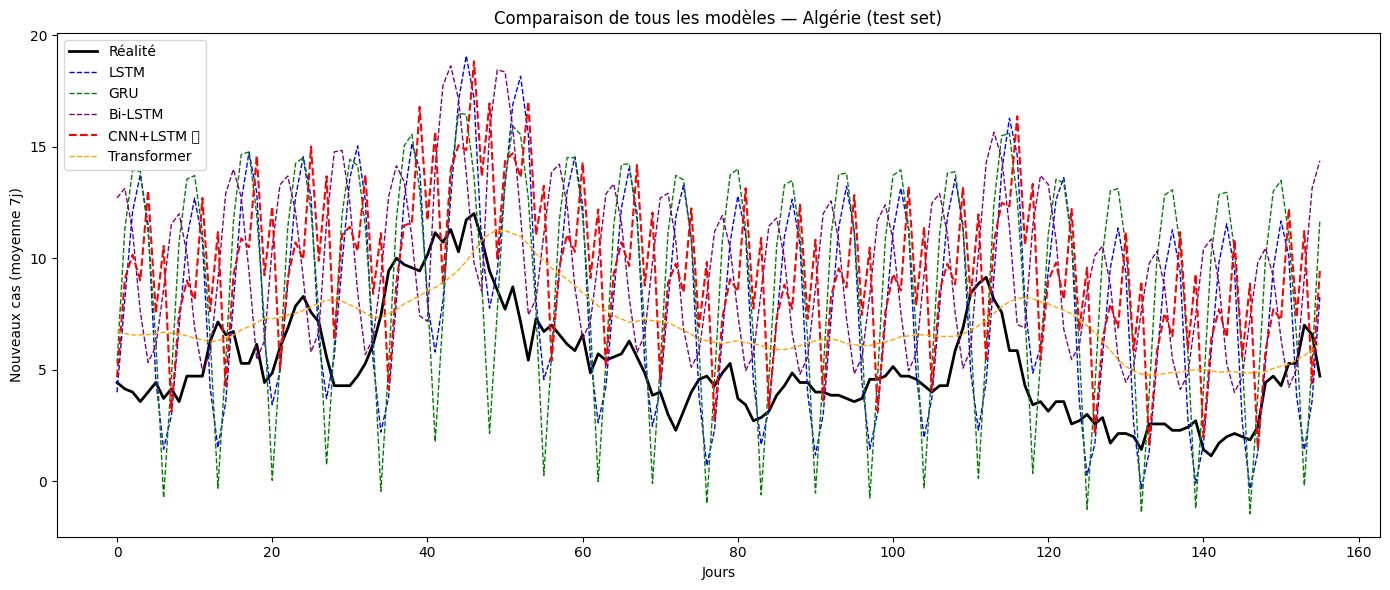

Graphique sauvegardé !


In [38]:
plt.figure(figsize=(14, 6))
plt.plot(y_true,         label="Réalité",      color="black",  lw=2)
plt.plot(y_pred_lstm,    label="LSTM",         color="blue",   lw=1, ls="--")
plt.plot(y_pred_gru,     label="GRU",          color="green",  lw=1, ls="--")
plt.plot(y_pred_bilstm,  label="Bi-LSTM",      color="purple", lw=1, ls="--")
plt.plot(y_pred_cnn,     label="CNN+LSTM ✅",  color="red",    lw=1.5, ls="--")
plt.plot(y_pred_transf,  label="Transformer",  color="orange", lw=1, ls="--")
plt.title("Comparaison de tous les modèles — Algérie (test set)")
plt.xlabel("Jours")
plt.ylabel("Nouveaux cas (moyenne 7j)")
plt.legend()
plt.tight_layout()
plt.savefig("../outputs/7_comparaison_modeles.png", dpi=150)
plt.show()
print("Graphique sauvegardé !")